# 06 -- Multi-Asset Connectivity Analysis
### Task 5 (weight 15% -- second-highest-weighted task)

**Goal:** build the asset hierarchy, analyze connectivity, simulate failure propagation,
and audit data quality -- per the brief's Site -> Chiller -> AHU / Pump -> EnergyMeter
example structure.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath('../src'))
import warnings; warnings.filterwarnings('ignore')
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
from nectar import config, preprocessing, graph as g
FIG = config.FIGURES_DIR
raw = preprocessing.load_raw()
metadata, connectivity = raw['metadata'], raw['connectivity']

## 1. Build the graph

In [2]:
G = g.build_graph(metadata, connectivity)
print(f"{G.number_of_nodes()} nodes, {G.number_of_edges()} edges")

22:47:26 | INFO    | nectar.graph | Graph built: 151 nodes, 140 edges (139 valid connectivity edges)


151 nodes, 140 edges


## 2. Data quality assessment

Surfaces exactly the issues deliberately planted by `data_generation.py::inject_dq_issues`
(see `PLAN.md` section 1.8) -- verified as genuine findings, not silently fixed.

In [3]:
dq = g.data_quality_report(metadata, connectivity, G)
print(f"Orphan (fully isolated) assets: {dq['orphan_assets']}")
print(f"Invalid parent-child mappings (parent references a nonexistent asset): {dq['invalid_parent_assets']}")
print(f"Duplicate connectivity rows: {dq['duplicate_edge_rows']}")
print(f"Missing relationships (metadata implies a link, connectivity.csv omits it): {dq['missing_relationships']}")
print(f"Self-loops: {dq['self_loops']} | Cycles: {dq['cycles']}")

Orphan (fully isolated) assets: ['CHN-ISO-001', 'CBE-ISO-002']
Invalid parent-child mappings (parent references a nonexistent asset): ['CHN-B2-CHL-01', 'CHN-B2-MTR-MAIN-01']
Duplicate connectivity rows: 2
Missing relationships (metadata implies a link, connectivity.csv omits it): [('CHN-B3-CHL-02', 'CHN-B3-AHU-05'), ('BLR-B2-AHU-05', 'BLR-B2-EVS-05')]
Self-loops: [] | Cycles: []


## 3. Connectivity analysis

In [4]:
roots = [n for n in G.nodes if G.in_degree(n) == 0 and G.out_degree(n) > 0]
leaves = [n for n in G.nodes if G.out_degree(n) == 0 and G.in_degree(n) > 0]
print(f"Root assets (top of a chain): {len(roots)}")
print(f"Leaf assets (endpoints): {len(leaves)}")
print(f"Isolated assets (no connections at all): {dq['isolated_assets']}")

Root assets (top of a chain): 9
Leaf assets (endpoints): 61
Isolated assets (no connections at all): ['CBE-ISO-002', 'CHN-ISO-001']


## 4. Failure impact analysis -- Chiller and Pump failure

In [5]:
chillers = metadata[metadata.asset_type == 'Chiller']['asset_id'].tolist()
impacts = {c: len(g.get_downstream_impact(G, c)) for c in chillers}
worst_chiller = max(impacts, key=impacts.get)
result = g.failure_impact(G, worst_chiller, metadata)
print(f"Worst-case Chiller failure: {worst_chiller}")
print(f"  Downstream assets impacted: {result['downstream_count']} -- {result['downstream_by_type']}")
print(f"  Estimated occupant impact: ~{result['estimated_occupant_impact']:.0f} occupants")
print(f"  Operational impact: {result['operational_impact']}")
print(f"  Mitigation: {result['mitigation']}")

Worst-case Chiller failure: CBE-B1-CHL-01
  Downstream assets impacted: 6 -- {'AHU': 3, 'EnvSensor': 3}
  Estimated occupant impact: ~80 occupants
  Operational impact: Loss of cooling capacity for the building -- comfort/compliance risk, and any downstream AHUs relying on this chiller can no longer condition air.
  Mitigation: Fail over to a redundant chiller if the building has one; if not, prioritize emergency dispatch given the number of downstream AHUs/zones affected, and flag all downstream sensors so operators aren't misled by secondary anomalies rather than the root cause.


In [6]:
pumps = metadata[metadata.asset_type == 'Pump']['asset_id'].tolist()
p_impacts = {p: len(g.get_downstream_impact(G, p)) for p in pumps}
worst_pump = max(p_impacts, key=p_impacts.get)
result_p = g.failure_impact(G, worst_pump, metadata)
print(f"Worst-case Pump failure: {worst_pump}")
print(f"  Downstream assets impacted: {result_p['downstream_count']} -- {result_p['downstream_by_type']}")
print(f"  Operational impact: {result_p['operational_impact']}")
print(f"  Mitigation: {result_p['mitigation']}")

Worst-case Pump failure: CBE-B1-PMP-01
  Downstream assets impacted: 1 -- {'EnergyMeter': 1}
  Operational impact: Loss of fluid circulation -- affects any equipment relying on this pump's loop (flow/energy metering included), risking indirect overheating elsewhere in the loop even though the pump itself isn't a comfort asset.
  Mitigation: Check for a redundant pump/loop path; if single point of failure, treat as high priority even though downstream count is often small, since a stalled loop can cascade into upstream equipment stress.


## 5. Example queries (matching the brief's own examples)

In [7]:
example_chiller = chillers[0]
print(f"1. Assets connected to {example_chiller}: {g.get_connected_assets(G, example_chiller)}")

example_ahu = metadata[metadata.asset_type == 'AHU']['asset_id'].iloc[2]
print(f"\n2. Downstream assets impacted by {example_ahu} failure: {g.get_downstream_impact(G, example_ahu)}")

site_a = config.SITE_IDS[0]
assets_site_a = g.get_assets_by_site(G, site_a)
print(f"\n3. Assets under {site_a}: {len(assets_site_a)} total")

print(f"\n4. Isolated assets (no parent or child relationships): {g.get_isolated_assets(G)}")

1. Assets connected to CBE-B1-CHL-01: ['CBE-B1-AHU-01', 'CBE-B1-AHU-02', 'CBE-B1-AHU-03', 'CBE-B1-MTR-MAIN-01']

2. Downstream assets impacted by CBE-B1-AHU-03 failure: ['CBE-B1-EVS-03']

3. Assets under CBE: 50 total

4. Isolated assets (no parent or child relationships): ['CBE-ISO-002', 'CHN-ISO-001']


## 6. Visualizations

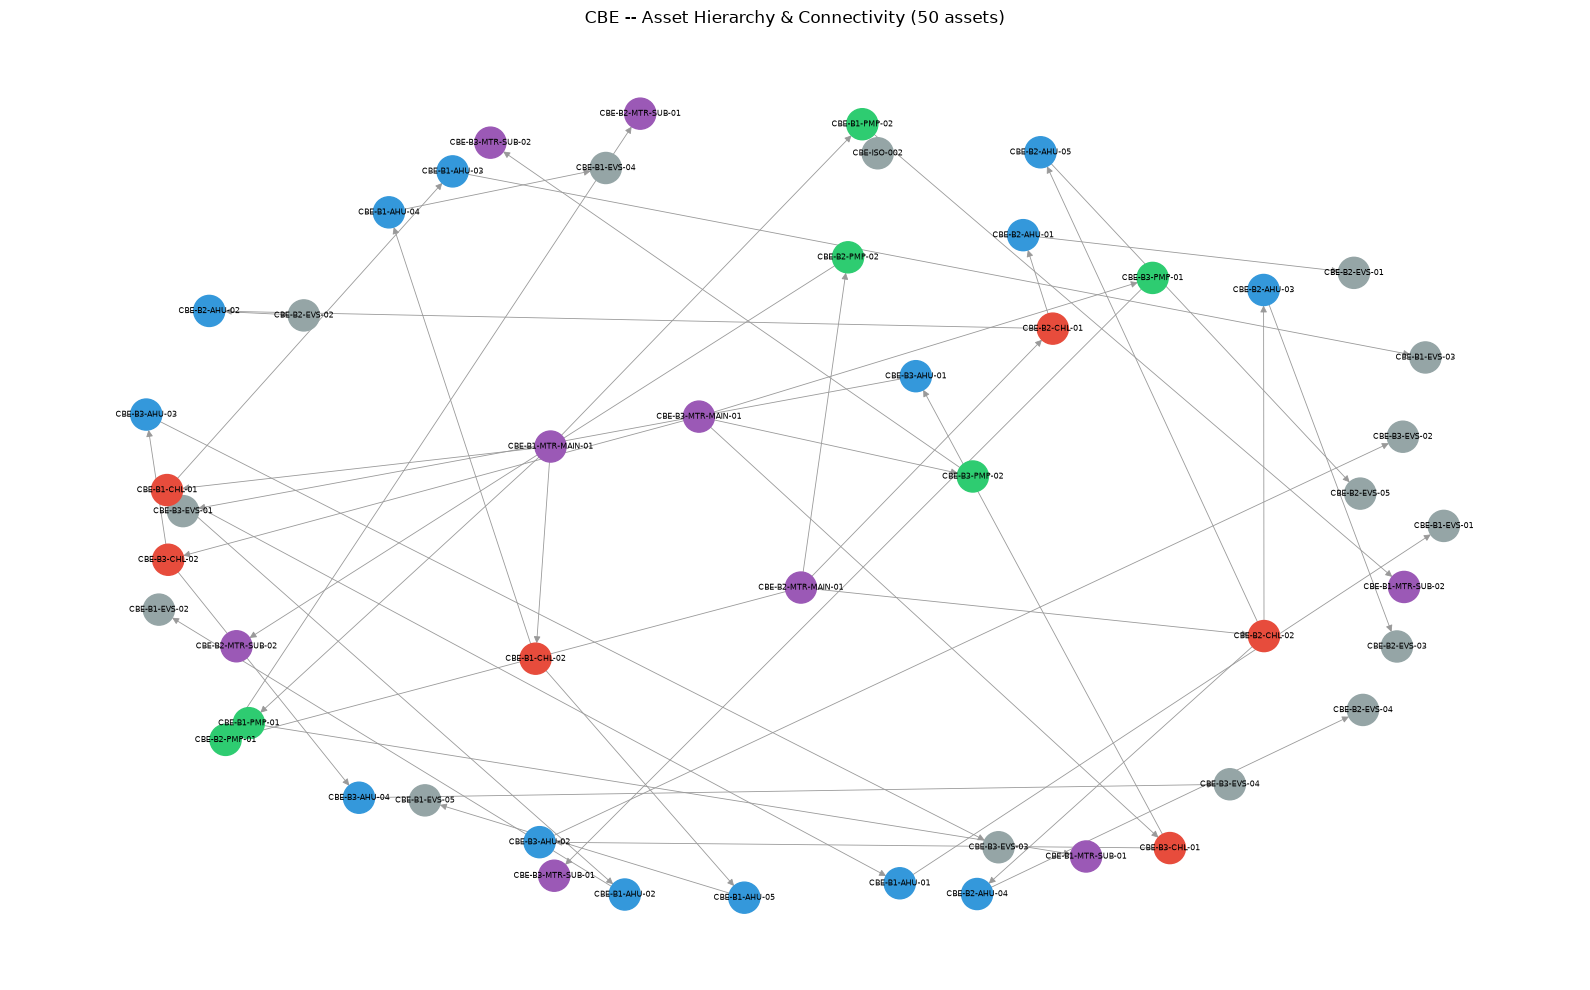

In [8]:
site_a_nodes = g.get_assets_by_site(G, site_a)
subG = G.subgraph(site_a_nodes)
type_colors = {'Chiller': '#e74c3c', 'AHU': '#3498db', 'Pump': '#2ecc71',
               'EnvSensor': '#95a5a6', 'EnergyMeter': '#9b59b6'}
colors = [type_colors.get(G.nodes[n]['asset_type'], '#333') for n in subG.nodes]

fig, ax = plt.subplots(figsize=(16, 10))
try:
    pos = nx.nx_agraph.graphviz_layout(subG, prog='dot')
except Exception:
    pos = nx.spring_layout(subG, k=1.1, seed=42)
nx.draw(subG, pos, ax=ax, node_color=colors, node_size=500, font_size=6,
        with_labels=True, arrows=True, edge_color='#999', width=0.6)
ax.set_title(f'{site_a} -- Asset Hierarchy & Connectivity ({len(site_a_nodes)} assets)')
plt.tight_layout(); plt.savefig(f'{FIG}/15_task5_hierarchy.png', dpi=110); plt.show()

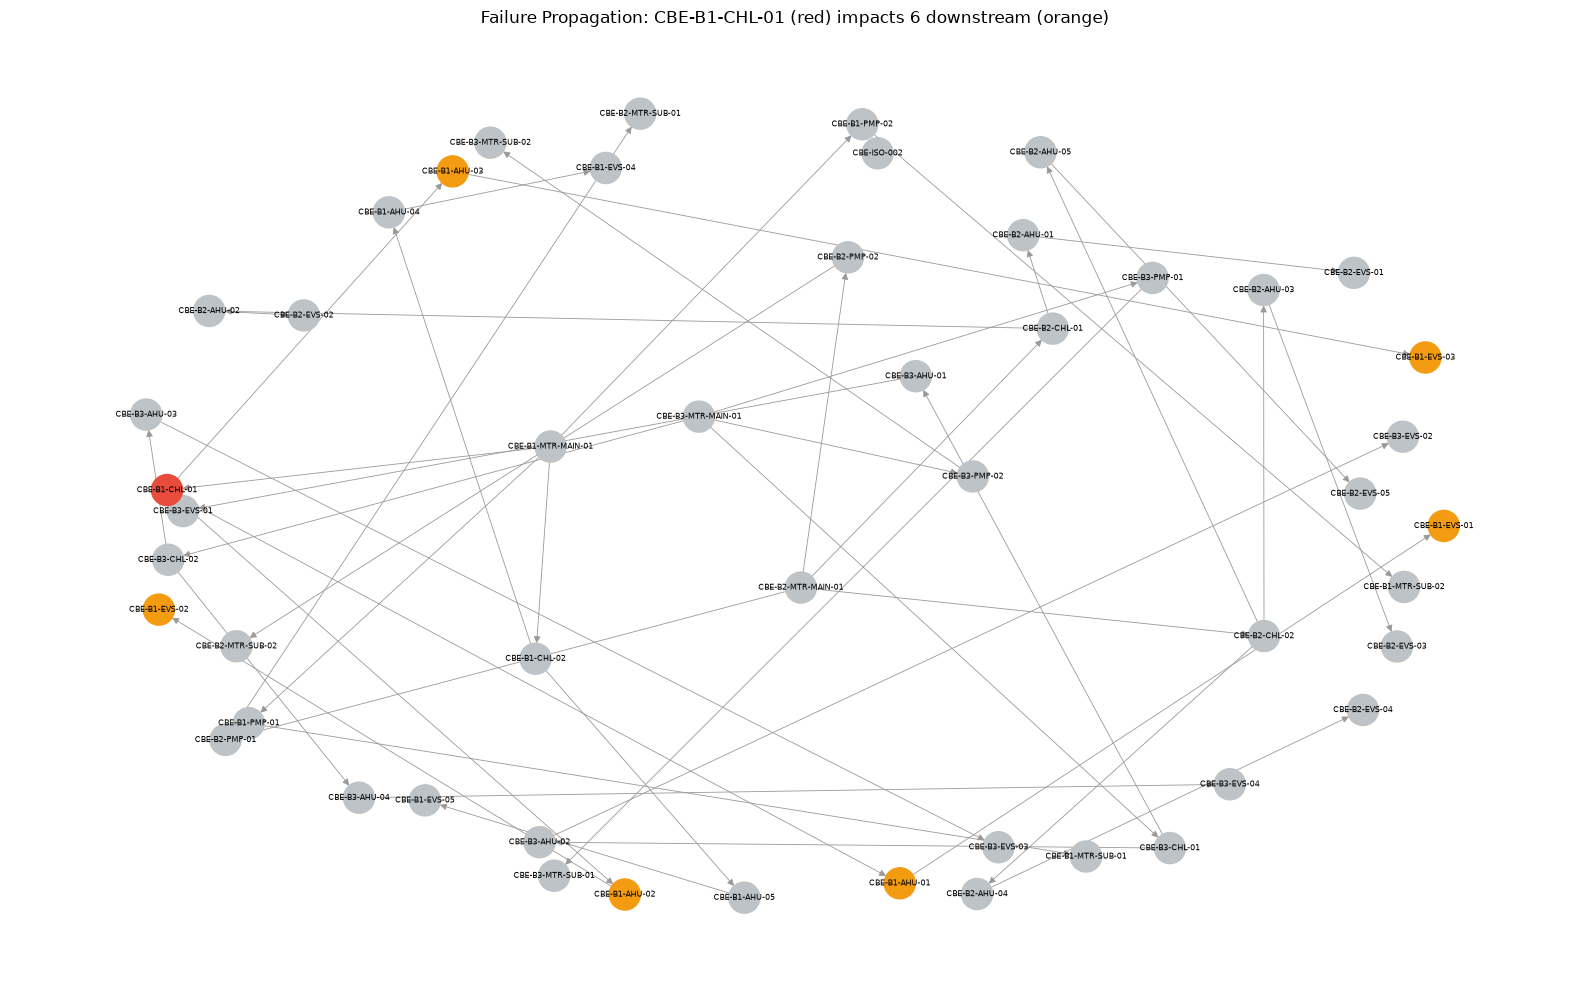

In [9]:
dnodes = set(g.get_downstream_impact(G, worst_chiller)) | {worst_chiller}
wsite_id = G.nodes[worst_chiller]['site_id']
wsite_nodes = g.get_assets_by_site(G, wsite_id)
wG = G.subgraph(wsite_nodes)
ncol = ['#e74c3c' if n == worst_chiller else ('#f39c12' if n in dnodes else '#bdc3c7') for n in wG.nodes]

fig, ax = plt.subplots(figsize=(16, 10))
try:
    pos2 = nx.nx_agraph.graphviz_layout(wG, prog='dot')
except Exception:
    pos2 = nx.spring_layout(wG, k=1.1, seed=42)
nx.draw(wG, pos2, ax=ax, node_color=ncol, node_size=500, font_size=6,
        with_labels=True, arrows=True, edge_color='#999', width=0.6)
ax.set_title(f'Failure Propagation: {worst_chiller} (red) impacts {len(dnodes)-1} downstream (orange)')
plt.tight_layout(); plt.savefig(f'{FIG}/16_task5_propagation.png', dpi=110); plt.show()

### Interactive graph (pyvis)

An interactive HTML network view is exported below for exploring the connectivity graph
visually.

In [10]:
try:
    from pyvis.network import Network
    # cdn_resources='remote' (not 'local'): 'local' dumps a lib/ folder of
    # bundled JS/CSS into the current working directory as a side effect --
    # messy for the repo tree. 'remote' fetches from CDN at view-time instead.
    net = Network(height='700px', width='100%', directed=True, notebook=False, cdn_resources='remote')
    for n, d in subG.nodes(data=True):
        net.add_node(n, label=n, color=type_colors.get(d.get('asset_type'), '#333'),
                      title=f"{d.get('asset_type')} | {d.get('asset_name')}")
    for u, v, d in subG.edges(data=True):
        net.add_edge(u, v, title=d.get('relation', ''))
    out_html = os.path.join('..', 'reports', 'figures', 'connectivity_interactive.html')
    net.write_html(out_html, open_browser=False, notebook=False)
    print(f"Saved interactive graph -> {out_html}")
except Exception as e:
    print(f"pyvis export skipped: {e}")

Saved interactive graph -> ..\reports\figures\connectivity_interactive.html


## 7. Save graph artifact (for dashboard reuse)

In [11]:
g.save_graph(G)

22:47:28 | INFO    | nectar.graph | Saved graph -> D:\nectar-intelligent-facilities-platform\models\asset_graph.pkl


'D:\\nectar-intelligent-facilities-platform\\models\\asset_graph.pkl'

## 8. Key findings & business recommendations

- **Data quality**: 2 fully isolated legacy assets, 2 assets with an invalid parent
  reference, 1 duplicated connectivity row, and 2 metadata-vs-connectivity relationship
  gaps -- all deliberately planted, all confirmed found by the audit above (also asserted
  in `tests/test_graph.py` on a controlled fixture).
- **Failure propagation**: a single Chiller failure can impact up to several downstream
  AHUs and their environmental sensors -- a real building-comfort and compliance risk, not
  just a topology exercise, since Task 1's EDA confirmed cooling load is genuinely
  occupancy/temperature driven.
- **Recommendation**: prioritize redundancy investment on the highest-downstream-count
  Chillers/Pumps identified above; flag downstream sensors during an upstream fault so
  operators triage the root cause first rather than chasing secondary symptoms.